In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

print("Libraries loaded ")

Libraries loaded 


In [2]:
df = pd.read_csv("../data/processed/cleaned_transactions.csv", parse_dates=['InvoiceDate'])

print("Shape:", df.shape)
df.head()

Shape: (805549, 9)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0


In [3]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

print("Snapshot date:", snapshot_date)

Snapshot date: 2011-12-10 12:50:00


In [4]:
rfm = df.groupby('Customer ID').agg(
    Recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency=('Invoice', 'nunique'),
    Monetary=('TotalPrice', 'sum')
).reset_index()

print("Shape:", rfm.shape)
rfm.head()

Shape: (5878, 4)


,Customer ID,Recency,Frequency,Monetary
0,12346,326,12,77556.46
1,12347,2,8,5633.32
2,12348,75,5,2019.40
3,12349,19,4,4428.69
4,12350,310,1,334.40


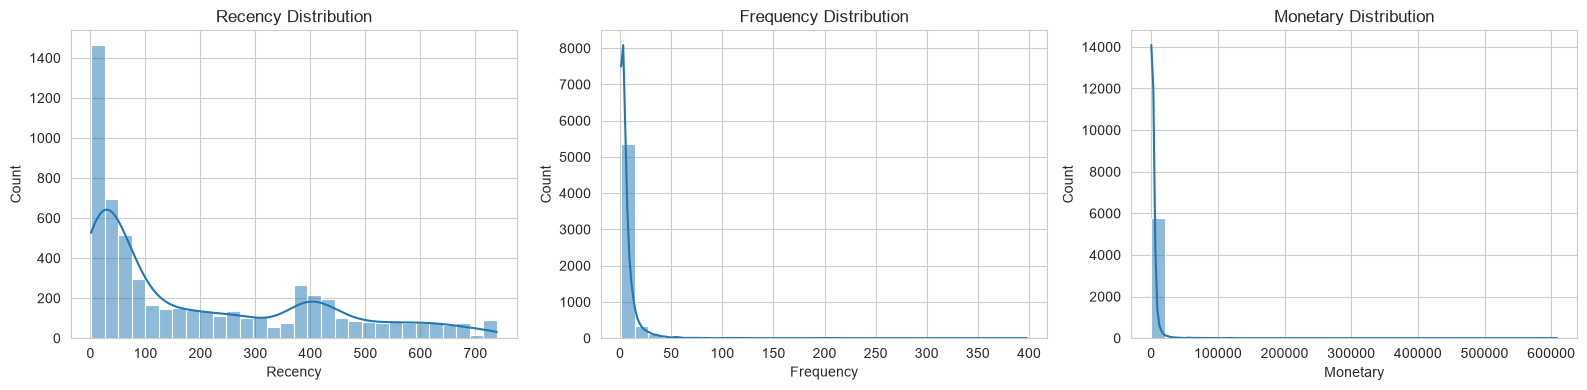

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.histplot(rfm['Recency'], bins=30, ax=axes[0], kde=True)
axes[0].set_title('Recency Distribution')

sns.histplot(rfm['Frequency'], bins=30, ax=axes[1], kde=True)
axes[1].set_title('Frequency Distribution')

sns.histplot(rfm['Monetary'], bins=30, ax=axes[2], kde=True)
axes[2].set_title('Monetary Distribution')

plt.tight_layout()

plt.savefig('../images/rfm_distributions.png', dpi=150)

plt.show()

In [7]:
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=5, labels=[1, 2, 3, 4, 5]).astype(int)

rfm.head()

,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score
0,12346,326,12,77556.46,2,5,5
1,12347,2,8,5633.32,5,4,5
2,12348,75,5,2019.40,3,4,4
3,12349,19,4,4428.69,5,3,5
4,12350,310,1,334.40,2,1,2


In [8]:
rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)
rfm['RFM_Score_Sum'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']

rfm[['Customer ID', 'R_Score', 'F_Score', 'M_Score', 'RFM_Score', 'RFM_Score_Sum']].head()

,Customer ID,R_Score,F_Score,M_Score,RFM_Score,RFM_Score_Sum
0,12346,2,5,5,255,12
1,12347,5,4,5,545,14
2,12348,3,4,4,344,11
3,12349,5,3,5,535,13
4,12350,2,1,2,212,5


In [9]:
def rfm_segment(row):
    r = row['R_Score']
    f = row['F_Score']

    if r >= 4 and f >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'New Customers'
    elif r == 3 and f <= 2:
        return 'Promising'
    elif r <= 2 and f >= 4:
        return 'At Risk'
    elif r <= 2 and f == 3:
        return 'Needs Attention'
    elif r <= 2 and f <= 2:
        return 'Lost'
    else:
        return 'Others'

rfm['Segment'] = rfm.apply(rfm_segment, axis=1)

rfm['Segment'].value_counts()

Segment
Lost               1523
Champions          1482
Loyal Customers    1221
Needs Attention     471
New Customers       443
Promising           385
At Risk             353
Name: count, dtype: int64

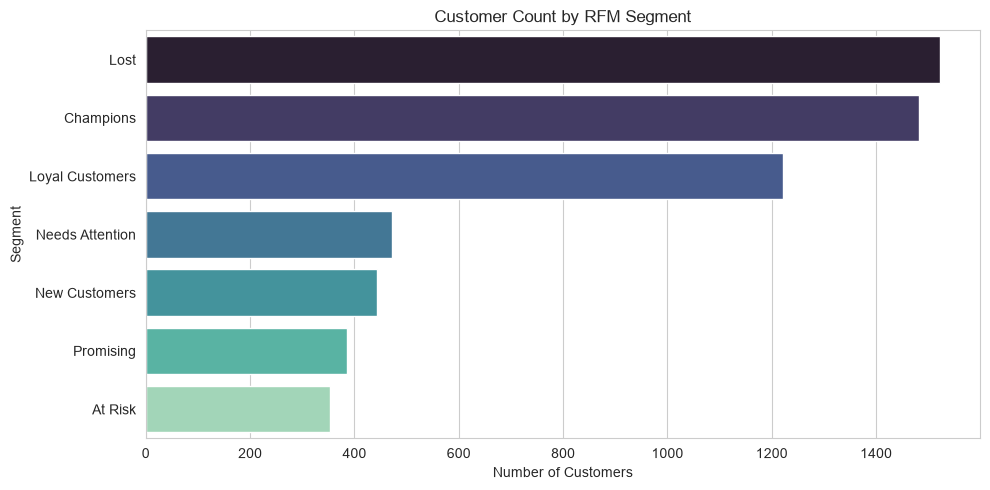

In [10]:
segment_counts = rfm['Segment'].value_counts()

plt.figure(figsize=(10, 5))

sns.barplot(
    x=segment_counts.values,
    y=segment_counts.index,
    hue=segment_counts.index,
    palette='mako',
    legend=False
)

plt.title('Customer Count by RFM Segment')
plt.xlabel('Number of Customers')
plt.ylabel('Segment')
plt.tight_layout()

plt.savefig('../images/rfm_segment_distribution.png', dpi=150)

plt.show()

In [11]:
segment_summary = rfm.groupby('Segment').agg(
    Customer_Count=('Customer ID', 'count'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean')
).round(1).sort_values('Avg_Monetary', ascending=False)

segment_summary

,Customer_Count,Avg_Recency,Avg_Frequency,Avg_Monetary
Segment,,,,
Champions,1482,20.4,15.7,8295.0
At Risk,353,344.2,7.6,3190.5
Loyal Customers,1221,78.6,5.4,2087.6
Needs Attention,471,387.8,3.0,1078.0
New Customers,443,28.1,1.5,890.8
Promising,385,107.1,1.4,534.1
Lost,1523,459.3,1.3,438.0


In [12]:
output_path = "../data/processed/rfm_table.csv"
rfm.to_csv(output_path, index=False)

print(f"Saved RFM table to {output_path}")
print("Final shape:", rfm.shape)

Saved RFM table to ../data/processed/rfm_table.csv
Final shape: (5878, 10)
